# Relative-tick FM panel

Fama–MacBeth-style panels: market-quality metrics vs **relative tick** $\tau/\mathrm{mid}$ on ETH across HL + Deribit + Kraken.

Pass 1: day/hour FM slopes for quoted/rel spread, BBO depth, volume.
Pass 2: time-split, markout-by-quartile, venue-colored scatters; vs mmip `tick.rel_tick_bps` (descriptor only).


## Setup


In [1]:
import sys, json
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import Image, display

ROOT = Path('/home/dev/srv/ares-microstructure')
sys.path.insert(0, str(ROOT))
from research.lib import ticksize

BOOK = Path('/home/dev/srv/ares-microstructure/research/books/mm_confr_viewpoints')
PASS1 = BOOK / 'out' / 'pass1'
PASS2 = BOOK / 'out' / 'pass2'
FIGS = BOOK / 'out' / 'rel_tick_panel' / 'figs'
OUT = BOOK / 'out' / 'rel_tick_panel'

panel = json.loads((PASS1 / 'panel.json').read_text())
fm = json.loads((PASS1 / 'fm.json').read_text())
hard = json.loads((PASS2 / 'hardening_gates.json').read_text())

pdf = pd.DataFrame([{
    'venue': r['venue'], 'day': r['day'], 'tau': r['tau'],
    'rel_tick': r['rel_tick'], 'rel_tick_bps': r['rel_tick_bps'],
    'quoted_spread_bps': r['quoted_spread_bps'], 'relative_spread': r['relative_spread'],
    'bbo_depth': r.get('bbo_depth'), 'volume': r['volume'],
    'markout_1s_bps': r.get('markout_1s_bps'), 'n_trades': r['n_trades'],
} for r in panel['rows']])
print('n_rows', len(pdf), 'days', panel.get('days'))
print(pdf[['venue', 'day', 'rel_tick_bps', 'quoted_spread_bps', 'volume', 'markout_1s_bps']].round(4).to_string(index=False))
print('ticksize.fama_macbeth_slope OK', callable(getattr(ticksize, 'fama_macbeth_slope', None)))


n_rows 9 days ['2026-09-26', '2026-09-27', '2026-09-30']
      venue        day  rel_tick_bps  quoted_spread_bps       volume  markout_1s_bps
hyperliquid 2026-09-26        0.3719             0.3719 9.995723e+04          1.0425
    deribit 2026-09-26        0.1860             3.7253 2.634792e+07        -29.2795
     kraken 2026-09-26        0.3720             1.5000 1.411617e+04          2.3586
hyperliquid 2026-09-27        0.3717             0.3717 1.388340e+05          1.3539
    deribit 2026-09-27        0.1858             3.5377 2.282505e+07         24.0659
     kraken 2026-09-27        0.3718             1.5000 1.883025e+04          2.3768
hyperliquid 2026-09-30        0.3734             0.3734 3.531766e+05          0.6589
    deribit 2026-09-30        0.1861             1.8616 9.272643e+07        149.8709
     kraken 2026-09-30        0.3731             1.5000 3.046774e+04          2.2999
ticksize.fama_macbeth_slope OK True


## Scatters (venue colors)

HL (blue) sits at ~1-tick quoted spreads; Deribit (orange) has smaller $\tau$ but wider quoted bps; Kraken (green) uses trade-synth BBO.


fig_scatter_spread.png


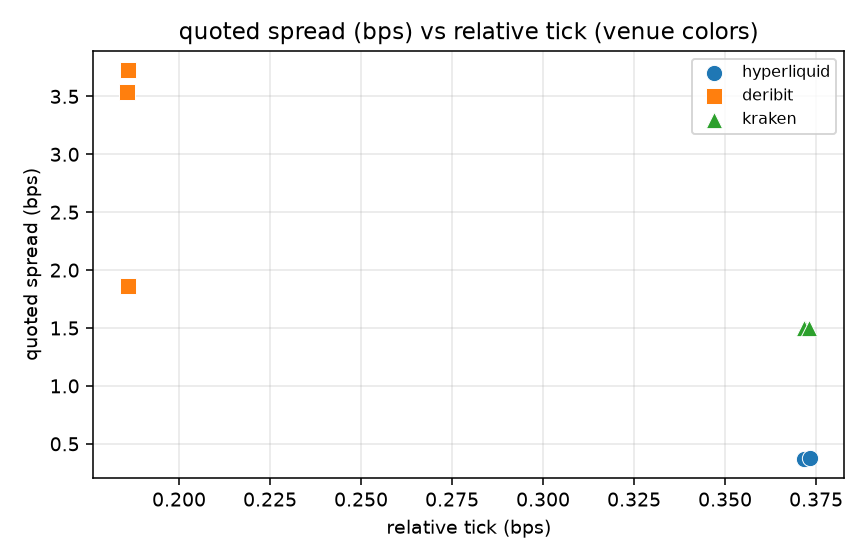

fig_scatter_volume.png


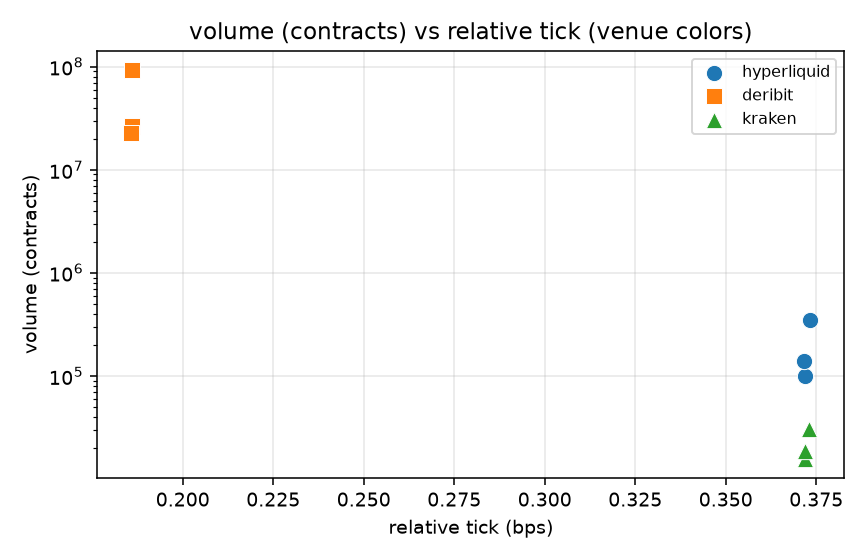

fig_scatter_depth.png


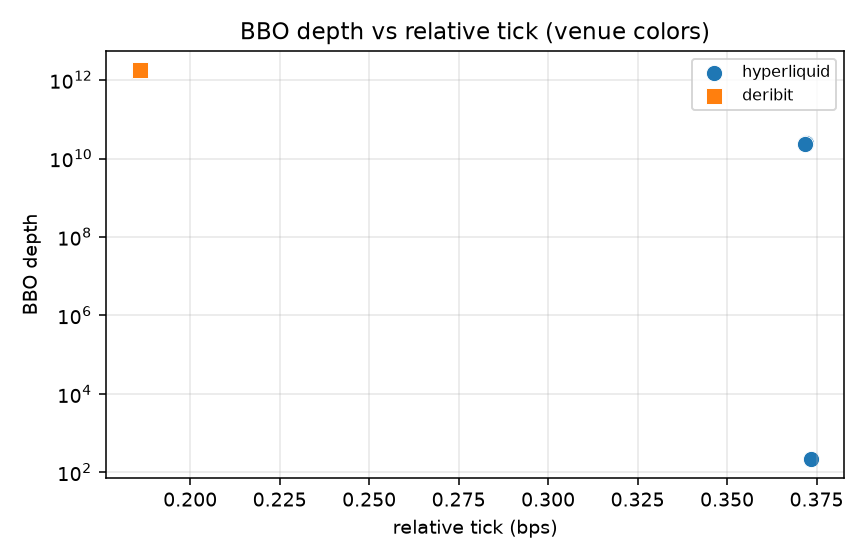

In [2]:
for fig in ['fig_scatter_spread.png', 'fig_scatter_volume.png', 'fig_scatter_depth.png']:
    p = FIGS / fig
    print(fig)
    display(Image(filename=str(p)))


## FM coefficients + CIs

Day-level FM: cross-section across venues within each UTC day, then average slopes. Hour-level FM uses hour buckets. **Caveat:** x-venue $\tau$-gap confounds the slope — Hold until within-venue FE.


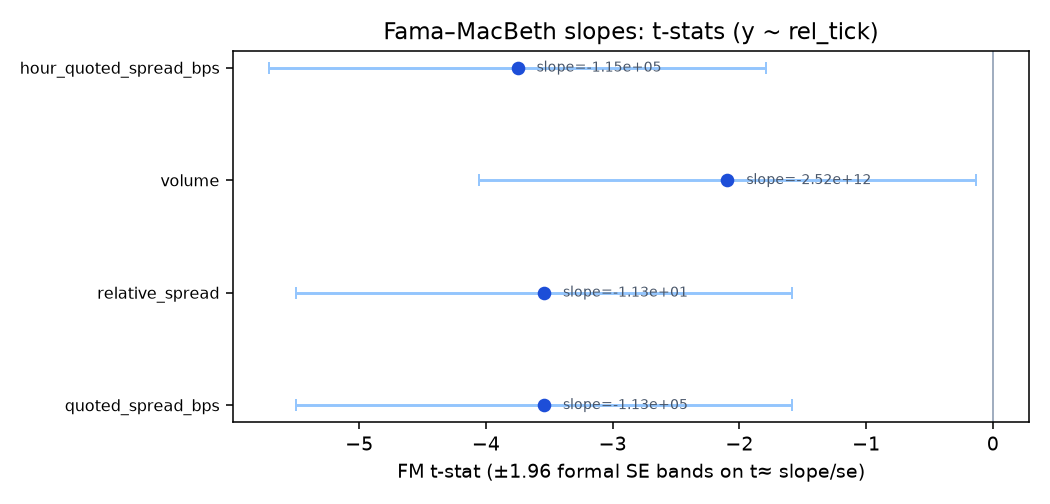

quoted_spread_bps            mean_slope=-113115.26756716466  se=31945.75632965232  t=-3.540854265584256  n_groups=3
bbo_depth                    mean_slope=nan  se=nan  t=nan  n_groups=0
volume                       mean_slope=-2527285963930.1587  se=1210173686193.75  t=-2.088366316969759  n_groups=3
relative_spread              mean_slope=-11.311526756716466  se=3.194575632965232  t=-3.540854265584256  n_groups=3
quoted_spread_bps_by_venue   mean_slope=-19443169.206807684  se=19448484.827005092  t=-0.9997266820400309  n_groups=3
hour_quoted_spread_bps       mean_slope=-115048.61668002074  se=30689.526410543505  t=-3.748790878718003  n_groups=3
hour_bbo_depth               mean_slope=-9.557287779397187e+16  se=2861748903032650.5  t=-33.39666792313311  n_groups=3


In [3]:
display(Image(filename=str(FIGS / 'fig_fm_coefs.png')))
for k, rec in fm.items():
    if not isinstance(rec, dict) or 'mean_slope' not in rec:
        continue
    print('{:28s} mean_slope={}  se={}  t={}  n_groups={}'.format(
        k, rec.get('mean_slope'), rec.get('se'), rec.get('t'), rec.get('n_groups')))


## Time-split falsifier

Early = first half of sample days; late = remainder (from `hardening_gates.json`). Promote would require consistent sign + finite $t$ in **both** halves.


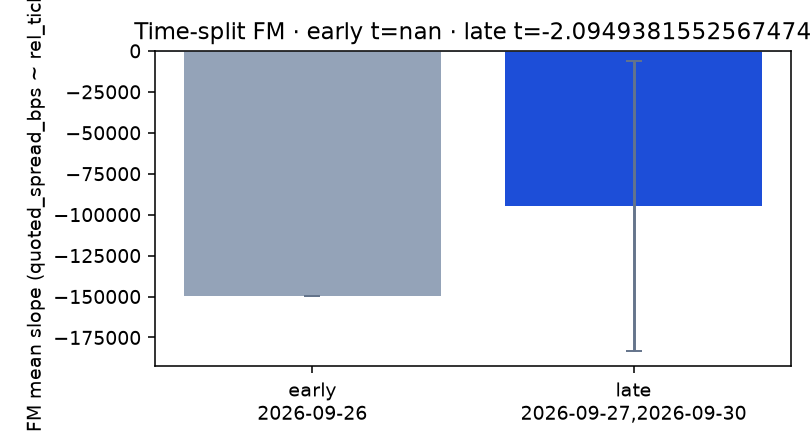

early days ['2026-09-26'] slope -149944.14400824063 t nan
late days  ['2026-09-27', '2026-09-30'] slope -94700.82934662666 t -2.0944953638858936
day_fm_t -3.540854265584256 hour_fm_t -3.748790878718003
xvenue_confound True
sign-consistent slopes: True
both t finite: False


In [4]:
display(Image(filename=str(FIGS / 'fig_time_split.png')))
early, late = hard.get('fm_early') or {}, hard.get('fm_late') or {}
print('early days', hard.get('early'), 'slope', early.get('mean_slope'), 't', early.get('t'))
print('late days ', hard.get('late'), 'slope', late.get('mean_slope'), 't', late.get('t'))
print('day_fm_t', hard.get('day_fm_t'), 'hour_fm_t', hard.get('hour_fm_t'))
print('xvenue_confound', (hard.get('flags') or {}).get('xvenue_confound'))
se_sign = np.sign(early.get('mean_slope')) == np.sign(late.get('mean_slope'))
t_early, t_late = early.get('t'), late.get('t')
both_t = (
    t_early is not None and t_late is not None
    and t_early == t_early and t_late == t_late
    and np.isfinite(float(t_early)) and np.isfinite(float(t_late))
)
print('sign-consistent slopes:', bool(se_sign))
print('both t finite:', bool(both_t))


## Markout by relative-tick quartile

Pass-2 info dig: 1s markout (bps) vs rel-tick quartile when `markout_1s_bps` is present on panel rows.


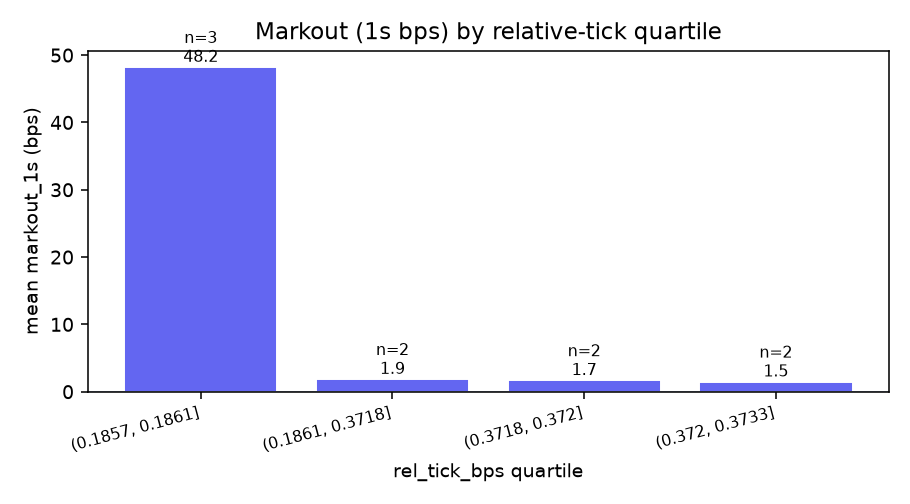

{
  "quartiles": [
    "(0.1857, 0.1861]",
    "(0.1861, 0.3718]",
    "(0.3718, 0.372]",
    "(0.372, 0.3733]"
  ],
  "mean_markout_1s_bps": [
    48.21909179141672,
    1.8653658581115664,
    1.691227387019206,
    1.4830038980919045
  ],
  "n": [
    3,
    2,
    2,
    2
  ]
}
venue markout means:
venue
deribit        48.219
hyperliquid     1.018
kraken          2.345
Name: markout_1s_bps, dtype: float64


In [5]:
display(Image(filename=str(FIGS / 'fig_markout_quartile.png')))
mq_path = OUT / 'markout_quartile.json'
if mq_path.exists():
    print(json.dumps(json.loads(mq_path.read_text()), indent=2))
else:
    q = pd.qcut(pdf['rel_tick_bps'], q=min(4, pdf['rel_tick_bps'].nunique()), duplicates='drop')
    print(pdf.groupby(q, observed=True)['markout_1s_bps'].agg(['mean', 'count']))
print('venue markout means:')
print(pdf.groupby('venue')['markout_1s_bps'].mean().round(3))


## vs mmip `tick.rel_tick_bps`

mmip Promotes `rel_tick_bps` as a **regime descriptor**. This chapter's object is the **FM slope / scorecard**, not a re-Promote of the same descriptor. Cross-link only.


In [6]:
print('panel rel_tick_bps describe:')
print(pdf['rel_tick_bps'].describe())
print('gate', hard.get('gates', {}).get('liq.fm_rel_tick_spread'))
print('gate', hard.get('gates', {}).get('liq.rho_rel_tick_spread'))


panel rel_tick_bps describe:
count    9.000000
mean     0.310196
std      0.093180
min      0.185813
25%      0.186107
50%      0.371789
75%      0.371982
max      0.373350
Name: rel_tick_bps, dtype: float64
gate {'decision': 'Hold', 'why': 'day FM t=-3.540854265584256; hour FM t=-3.748790878718003; early t=nan late t=-2.0944953638858936; xvenue τ-gap confound — not clean within-venue FM'}
gate {'decision': 'Hold', 'why': 'Spearman ρ=-0.6 CI95=[-0.917,0.242] n=9'}


## Inline: hour-bucket scatter + FM CI table


n_hour_rows 152


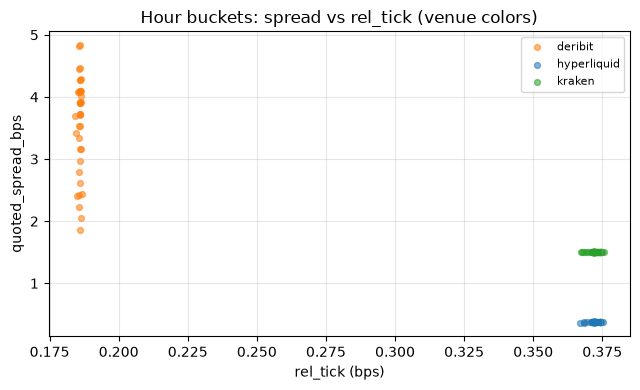

                         y    mean_slope           se          t       ci95_lo       ci95_hi  n_groups
         quoted_spread_bps -1.131153e+05 3.194576e+04  -3.540854 -1.757289e+05 -5.050159e+04         3
                 bbo_depth           NaN          NaN        NaN           NaN           NaN         0
                    volume -2.527286e+12 1.210174e+12  -2.088366 -4.899226e+12 -1.553455e+11         3
           relative_spread -1.131153e+01 3.194576e+00  -3.540854 -1.757289e+01 -5.050159e+00         3
quoted_spread_bps_by_venue -1.944317e+07 1.944848e+07  -0.999727 -5.756220e+07  1.867586e+07         3
    hour_quoted_spread_bps -1.150486e+05 3.068953e+04  -3.748791 -1.752001e+05 -5.489714e+04         3
            hour_bbo_depth -9.557288e+16 2.861749e+15 -33.396668 -1.011819e+17 -8.996385e+16         3


In [7]:
import matplotlib.pyplot as plt

# flatten hour rows
hours = []
for r in panel['rows']:
    for h in r.get('hour_rows') or []:
        hours.append(h)
hdf = pd.DataFrame(hours)
print('n_hour_rows', len(hdf))

fig, ax = plt.subplots(figsize=(6.5, 4.0))
vc = {'hyperliquid':'#1f77b4','deribit':'#ff7f0e','kraken':'#2ca02c'}
for v, g in hdf.groupby('venue'):
    ax.scatter(g['rel_tick'] * 1e4, g['quoted_spread_bps'], s=18, alpha=0.55, c=vc.get(v,'#666'), label=v)
ax.set_xlabel('rel_tick (bps)'); ax.set_ylabel('quoted_spread_bps')
ax.set_title('Hour buckets: spread vs rel_tick (venue colors)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

# FM CI table
rows = []
for k, rec in fm.items():
    if not isinstance(rec, dict) or 'mean_slope' not in rec:
        continue
    m, se, t = rec.get('mean_slope'), rec.get('se'), rec.get('t')
    lo = hi = None
    if se is not None and m is not None and se == se and m == m:
        lo, hi = m - 1.96 * se, m + 1.96 * se
    rows.append({'y': k, 'mean_slope': m, 'se': se, 't': t, 'ci95_lo': lo, 'ci95_hi': hi, 'n_groups': rec.get('n_groups')})
fmdf = pd.DataFrame(rows)
print(fmdf.to_string(index=False))


## Inline: markout quartile recomputation


In [8]:
q = pd.qcut(pdf['rel_tick_bps'], q=min(4, pdf['rel_tick_bps'].nunique()), duplicates='drop')
tab = pdf.assign(rt_q=q).groupby('rt_q', observed=True).agg(
    mean_markout=('markout_1s_bps', 'mean'),
    n=('markout_1s_bps', 'count'),
    mean_rel_bps=('rel_tick_bps', 'mean'),
    mean_qs=('quoted_spread_bps', 'mean'),
)
print(tab.round(3))
print('Pearson(rel_tick_bps, markout_1s_bps) =', float(pdf['rel_tick_bps'].corr(pdf['markout_1s_bps'])))


                  mean_markout  n  mean_rel_bps  mean_qs
rt_q                                                    
(0.1857, 0.1861]        48.219  3         0.186    3.042
(0.1861, 0.3718]         1.865  2         0.372    0.936
(0.3718, 0.372]          1.701  2         0.372    0.936
(0.372, 0.3734]          1.479  2         0.373    0.937
Pearson(rel_tick_bps, markout_1s_bps) = -0.4509174177086405


## Promote / Hold / Kill

| ID | Decision | Falsifier |
|----|----------|-----------|
| `liq.fm_rel_tick_spread` | **Hold** | time-split early t=nan / late t≈−2.09; x-venue confound |
| `liq.fm_rel_tick_depth` | **Hold** | thin / non-comparable BBO units across venues |
| `info.markout_by_rel_tick` | **Hold** | n=9 day-rows; need denser join |
| `liq.rho_rel_tick_spread` | **Hold** | Spearman ρ=−0.6 CI includes 0 |

No Promote without within-venue FE or wider sample clearing time-split.
